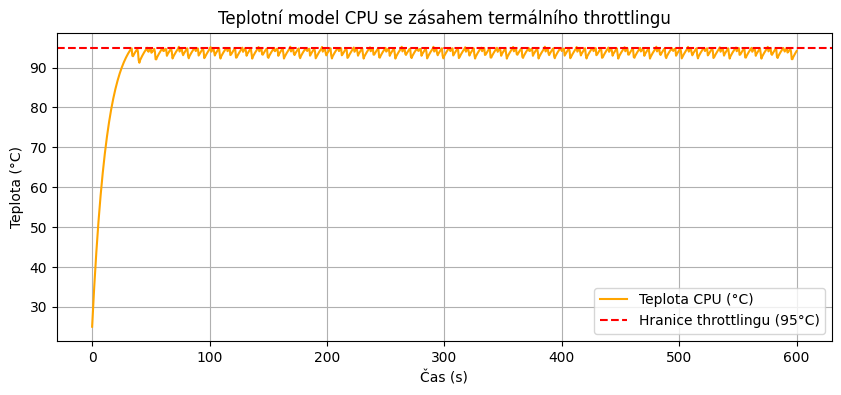

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =============================================================================
# Vlastní model (Soustava obyčejných diferenciálních rovnic):
# Teplotní dynamika procesoru v herním notebooku pod zátěží a efekt termálního throttlingu.
# =============================================================================""

def cpu_thermal_model(t, T, T_ambient, P_max, C_heat, k_cooling, T_throttle):
    # Ochrana proti přehřátí: snížení výkonu CPU na 30 %
    if T > T_throttle:
        P_in = P_max * 0.3
    else:
        P_in = P_max

    # dT/dt = (Přísun tepla - Ztráta tepla chlazením) / Tepelná kapacita
    dT_dt = (P_in - k_cooling * (T - T_ambient)) / C_heat
    return dT_dt

# Parametry pro simulaci
T_ambient = 25.0
P_max = 90.0 # Maximální příkon (W)
C_heat = 15.0 # Tepelná kapacita chladiče (J/K)
k_cooling = 1.2 # Koeficient odvodu tepla (W/K)
T_throttle = 95.0 # Kritická teplota

t_span = (0, 600)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

sol = solve_ivp(cpu_thermal_model, t_span, [T_ambient], t_eval=t_eval,
                args=(T_ambient, P_max, C_heat, k_cooling, T_throttle))

plt.figure(figsize=(10, 4))
plt.plot(sol.t, sol.y[0], color='orange', label='Teplota CPU (°C)')
plt.axhline(T_throttle, color='red', linestyle='--', label='Hranice throttlingu (95°C)')
plt.title('Teplotní model CPU se zásahem termálního throttlingu')
plt.xlabel('Čas (s)')
plt.ylabel('Teplota (°C)')
plt.legend()
plt.grid(True)
plt.show()

Závěr z modelu:
- Lze pozorovat strmý nárůst teploty bezprostředně po spuštění plné zátěže.
- Při dosažení 95 °C nastává skokové snížení výkonu (throttling), díky čemuž nedojde ke zničení čipu a teplota se stabilizuje.